Lab 4 - Generating CDF's

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

****Q1****

**1.** 
Set up a grid of K equally spaced values between 0 and 1

In [3]:
K = 3
N = 5_000

x = np.arange(0, 1, 1/K).round(2)
y = np.arange(0, 1, 1/K).round(2)

xx, yy = np.meshgrid(x, y)


coords = list(zip(xx.reshape(-1), yy.reshape(-1)))
points = [f'Point{i}' for i in range(1, len(xx.reshape(-1)) + 1)]

df = pd.DataFrame({'Points': points, 'Coords': coords, 'X': xx.reshape(-1), 'Y': yy.reshape(-1)})
sampled_df = df.sample(n = N, replace = True, ignore_index = True)

**2.**
Draw a point from the grid at random with equal probability

In [4]:
sampled_df = df.sample(n = N, replace = True, ignore_index = True)

**3.** For a very small K, repeat the above process n=5000 times, and plot the ECDF of the draws. 

Text(0.5, 1.0, 'Points as Tuples (x,y)\nK = 3')

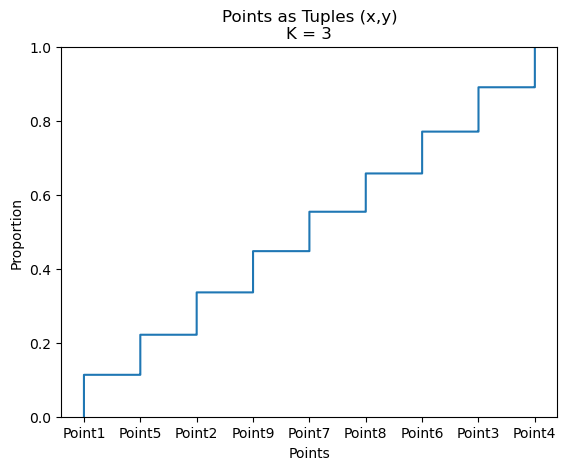

In [5]:
sns.ecdfplot(data = sampled_df, x='Points').set_title("Points as Tuples (x,y)\nK = 3")

Text(0.5, 1.0, 'Points as X coordinates (x)\nK = 3')

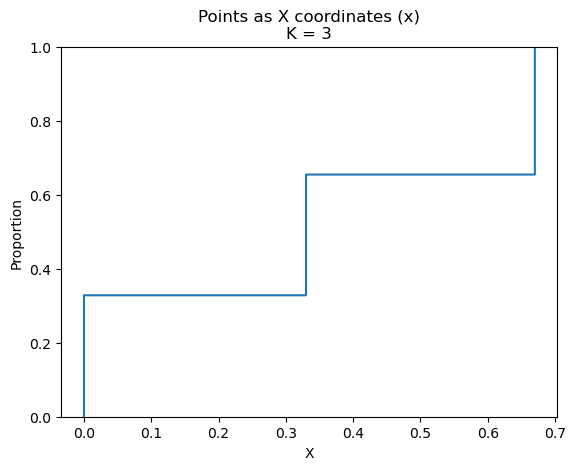

In [6]:
sns.ecdfplot(data = sampled_df, x='X').set_title("Points as X coordinates (x)\nK = 3")

Text(0.5, 1.0, 'Points as Y coordinates (y)\nK = 3')

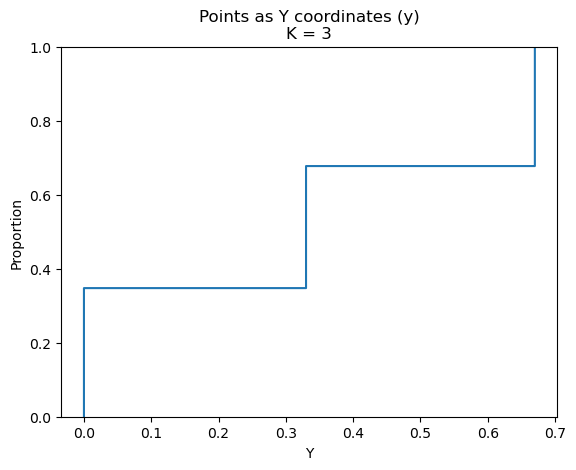

In [7]:
sns.ecdfplot(data = sampled_df, x='Y').set_title("Points as Y coordinates (y)\nK = 3")

**4.** What distribution does this approach as you increase K?

As K increases, the ECDF approaches the Uniform Distribution which presents as a straight positive line. 

In [8]:
K = 10
N = 5_000

x = np.arange(0, 1, 1/K).round(2)
y = np.arange(0, 1, 1/K).round(2)

xx, yy = np.meshgrid(x, y)


coords = list(zip(xx.reshape(-1), yy.reshape(-1)))
points = [f'Point{i}' for i in range(1, len(xx.reshape(-1)) + 1)]

df = pd.DataFrame({'Points': points, 'Coords': coords, 'X': xx.reshape(-1), 'Y': yy.reshape(-1)})
sampled_df = df.sample(n = N, replace = True, ignore_index = True)

Text(0.5, 1.0, 'Points as Tuples (x,y)\nK = 10')

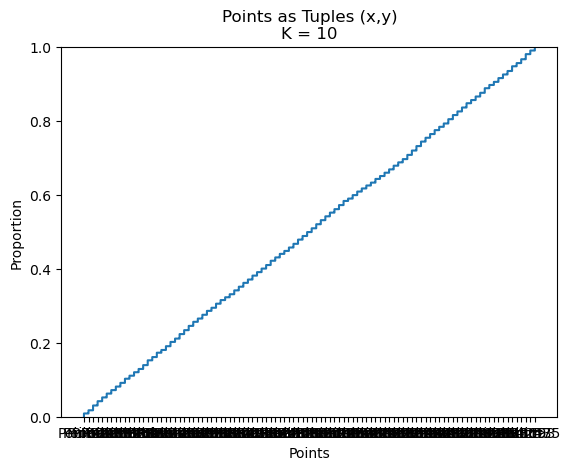

In [9]:
sns.ecdfplot(data = sampled_df, x='Points').set_title("Points as Tuples (x,y)\nK = 10")

Text(0.5, 1.0, 'Points as X coordinates (x)\nK = 10')

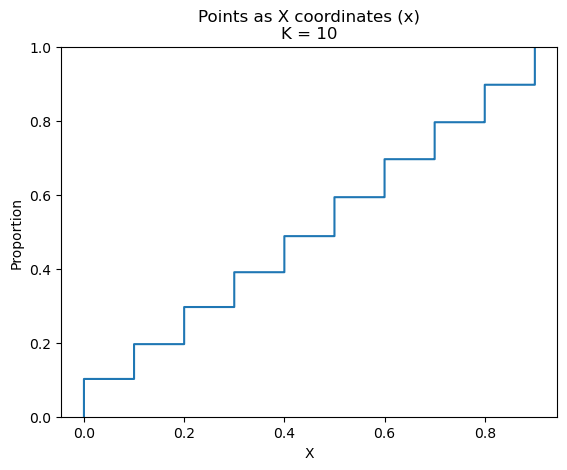

In [10]:
sns.ecdfplot(data = sampled_df, x='X').set_title("Points as X coordinates (x)\nK = 10")

Text(0.5, 1.0, 'Points as Y coordinates (y)\nK = 10')

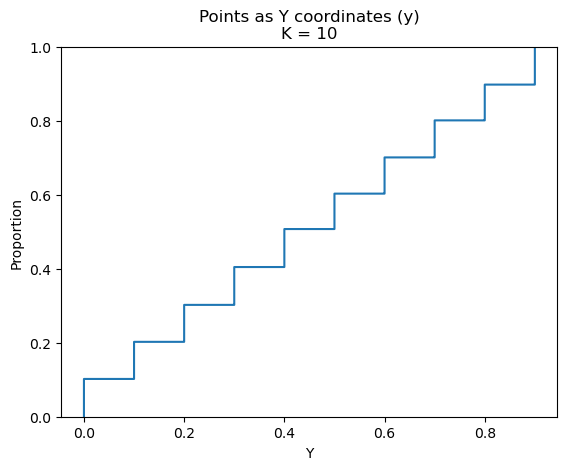

In [11]:
sns.ecdfplot(data = sampled_df, x='Y').set_title("Points as Y coordinates (y)\nK = 10")

Text(0.5, 1.0, 'Uniform CDF')

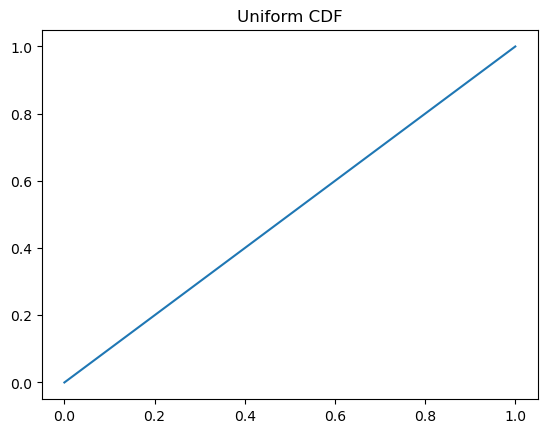

In [12]:
#Plot Uniform ECDF
from scipy.stats import uniform
x = np.linspace(0, 1, 100)
y = uniform.cdf(x, loc=0, scale = 1)

plt.plot(x, y)
plt.title("Uniform CDF")

****Q2****

**1.**
Draw n=32 values from uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of sqrt(+-3) ensures each draw has mean 0 and variance 1. 

In [13]:
rng = np.random.default_rng()
n = 32
x = rng.uniform(low = -1*np.sqrt(3), high = np.sqrt(3), size = n)
x

array([-1.04264353, -0.18004372,  1.35950427, -0.30557357, -0.05619138,
       -0.05386196, -1.14696431,  0.38600521,  0.52912122,  0.07905043,
        0.20504271,  0.46113065,  1.07594117, -0.22773401,  0.08149376,
        1.53248827, -0.53592895,  1.71385776,  1.66140019, -1.58836829,
       -0.08130482, -0.57297371, -0.18655826, -1.38414378,  1.34077436,
       -0.67892085,  1.47493875,  0.28694108, -1.19999965, -1.06797905,
       -0.18490538,  0.87264471])

**2.** For this sample, compute the mean and multiply by np.sqrt(n).

In [14]:
x.mean() * np.sqrt(n)

np.float64(0.4536513057321388)

**3.** Repeat the above process b = 5000 times and plot the ECDF.

In [15]:
b = 5_000
means = []
count = 0

while count < b:
    x = rng.uniform(low = -1*np.sqrt(3), high = np.sqrt(3), size = n)
    a = x.mean() * np.sqrt(n)
    means.append(a)
    count += 1


Text(0.5, 1.0, 'ECDF n = 32')

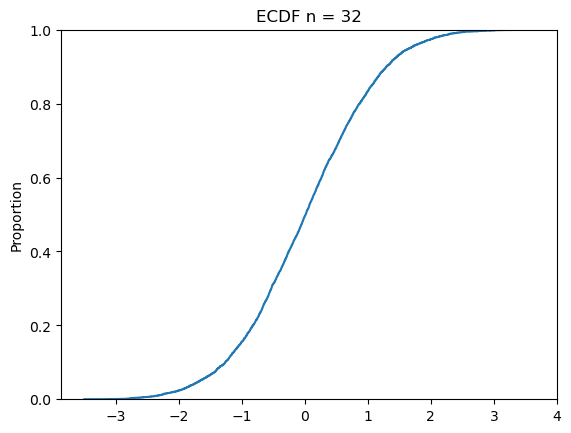

In [16]:
sns.ecdfplot(means)
plt.title("ECDF n = 32")

**4.** What distribution does this approach as n increases?

As n increases, the ECDF approaches the Normal distribution ECDF, which is S shaped. 

Text(0.5, 1.0, 'ECDF n = 100')

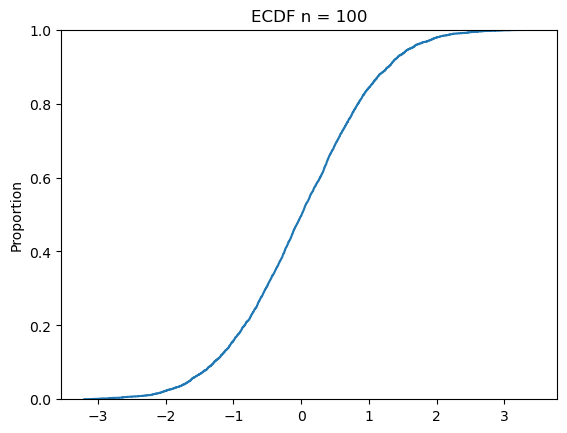

In [17]:
n = 100
b = 5_000
means = []
count = 0

while count < b:
    x = rng.uniform(low = -1*np.sqrt(3), high = np.sqrt(3), size = n)
    a = x.mean() * np.sqrt(n)
    means.append(a)
    count += 1

sns.ecdfplot(means)
plt.title("ECDF n = 100")

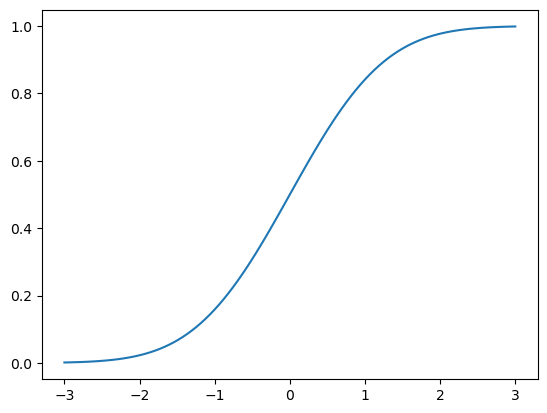

In [18]:
from scipy.stats import norm

x = np.linspace(-3, 3, 100)
y = norm.cdf(x)

plt.plot(x, y, label = 'Normal CDF')

****Q3****

**1.** Flip n = 40 coins, which each come up heads with probability p = 1/2 and tails with complementary probability. 

In [19]:
n = 40
p = 1/2
outcomes = []
count = 0
while count < n:
    c = random.choice([0, 1])
    outcomes.append(c)
    count += 1

sum(outcomes), len(outcomes)

(25, 40)

**2.** From the final count of heads, subtract the expected number of heads

In [20]:
sum(outcomes) - (n*p)

5.0

**3.** Divide by the standard deviation sqrt(n*p*(1-p))

In [21]:
(sum(outcomes) - (n*p))/(np.sqrt(n*p*(1-p)))

np.float64(1.5811388300841895)

**4.** Repeat above process b = 5000 times and plot the ECDF

In [22]:
heads = []
p = 1/2
q = 1-p
b = 5_000
n = 40

for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)



Text(0.5, 1.0, 'ECDF Coins')

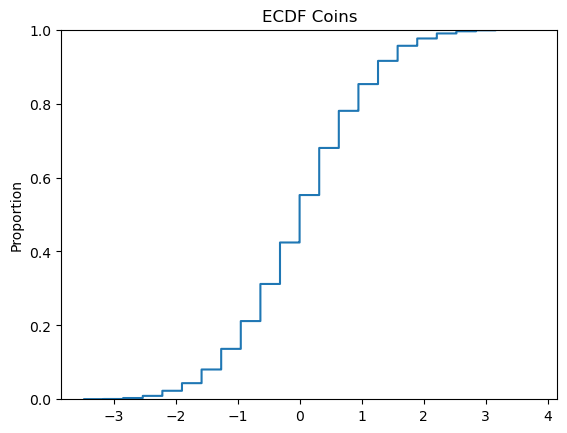

In [23]:
sns.ecdfplot(heads)
plt.title("ECDF Coins")

**5.** What distribution does this approach as n increases?

As n increases, the distribution approaches the binomial distribution. The overall S shape is similar to the normal distribution, but the data is discrete in this scenario so the steps in the ECDF do not smooth out, meaning it is a binomial ECDF. 

Text(0.5, 1.0, 'ECDF n = 1000')

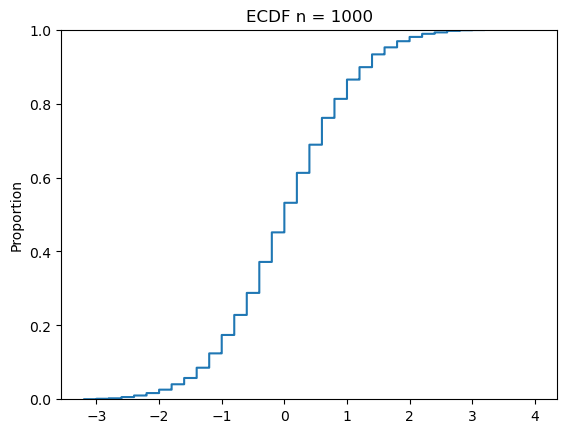

In [24]:
heads = []
p = 1/2
q = 1-p
b = 5_000
n = 100

for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)

sns.ecdfplot(heads)
plt.title("ECDF n = 1000")

Text(0.5, 1.0, 'Binomial ECDF')

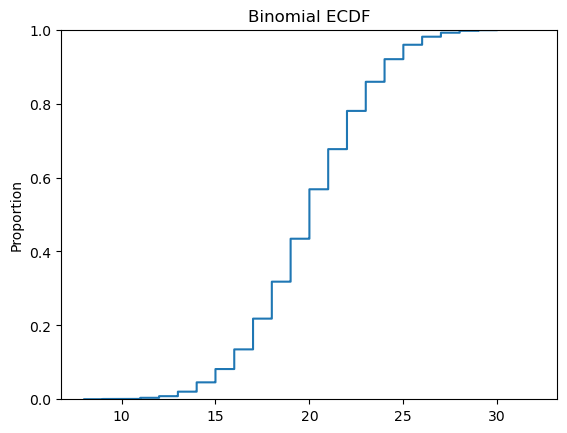

In [25]:
from scipy.stats import binom

n = 40
p = 1/2
b = 5_000

bin_vals = np.random.binomial(n = n, p = p, size = b)
sns.ecdfplot(bin_vals)
plt.title("Binomial ECDF")

**6. How do the results change as you adjust p?

When p is decreased to 1/4 compared to 1/2, nothing much changes in the ECDF other than the positive sidde of the range extending a little more to include 4. When p is increased to 3/4, the range favors negative numbers and has a slight extra hump in the curve in the middle. These occur because the computation formula changes for different values of p. When p is bigger, the total sum of heads increases, the expected value increases, the computed value decreases (denominator becomes larger), and vice versa for smaller p. 

Text(0.5, 1.0, 'ECDF n = 1000\np = 1/4')

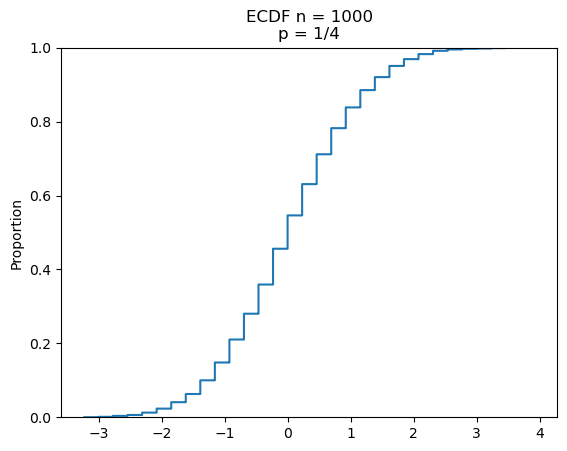

In [26]:
heads = []
p = 1/4
q = 1-p
b = 5_000
n = 100

for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)

sns.ecdfplot(heads)
plt.title("ECDF n = 1000\np = 1/4")

Text(0.5, 1.0, 'ECDF n = 1000\np = 3/4')

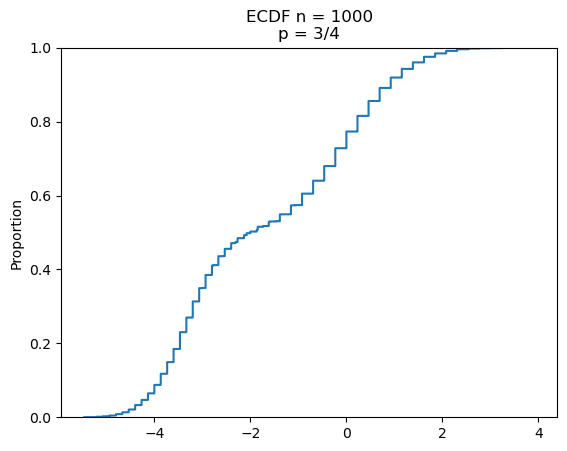

In [27]:
p = 3/4
for i in range(0, b):
    c = random.choices([0, 1], weights = [q, p], k = n)
    d = (sum(c) - (n*p)) / np.sqrt(n*p*q)
    heads.append(d)

sns.ecdfplot(heads)
plt.title("ECDF n = 1000\np = 3/4")

****Q5****

**1.** Draw K = 20 values from Uniform[0,1]

In [28]:
K = 20
rng = np.random.default_rng()
values = rng.uniform(0, 1, size = K)

**2.** Sort them by size from smallest to largest

In [29]:
values = np.sort(values)


**3.** Record the largest value

In [30]:
max(values)

np.float64(0.9400494741121697)

**4.** Repeat n times and plot the ECDF

Text(0.5, 1.0, 'Largest Rank')

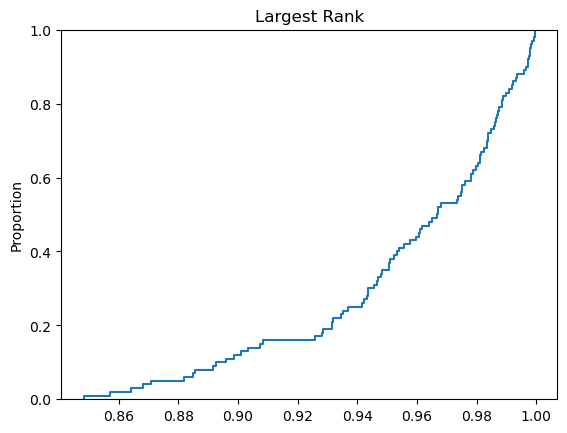

In [32]:
n = 100
K = 20
count = 0
ranked = []

while count < n:
    rng = np.random.default_rng()
    values = rng.uniform(0, 1, size = K)
    ranked.append(max(values))
    count += 1

sns.ecdfplot(ranked)
plt.title("Largest Rank")

**5.** Repeat for each rank

In [35]:
def K_rank(n, K, rank):
    count = 0
    ranked = []

    while count < n:
        rng = np.random.default_rng()
        values = rng.uniform(0, 1, size = K)
        ranked.append(values[rank-1])
        count += 1

    sns.ecdfplot(ranked)
    plt.title(f"Rank {rank}")

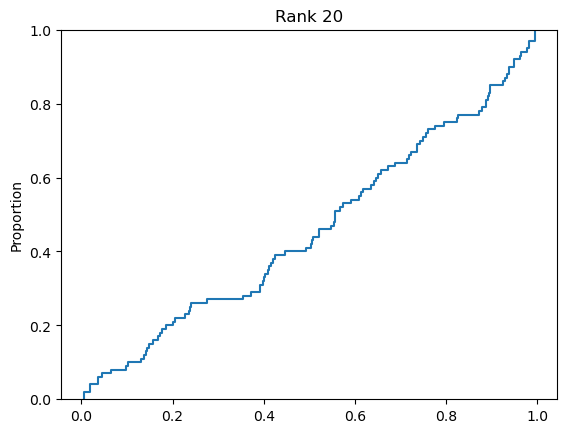

In [36]:
K_rank(n = 100, K = 20, rank = 20)

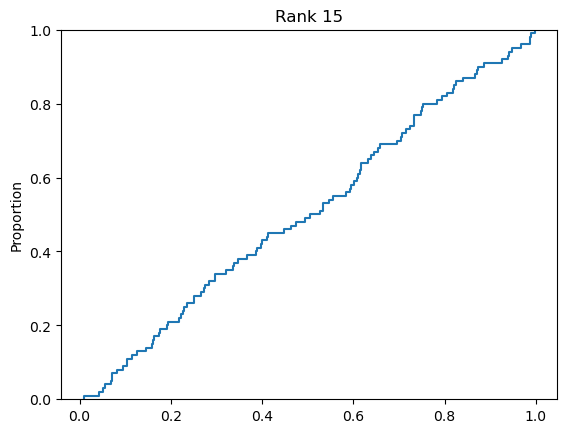

In [37]:
K_rank(n = 100, K = 20, rank = 15)

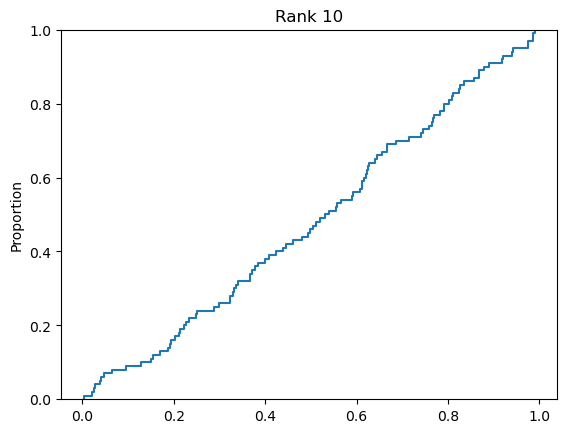

In [38]:
K_rank(n = 100, K = 20, rank = 10)

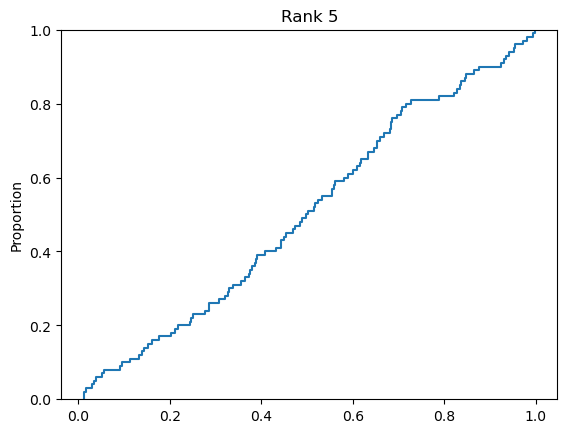

In [39]:
K_rank(n = 100, K = 20, rank = 5)

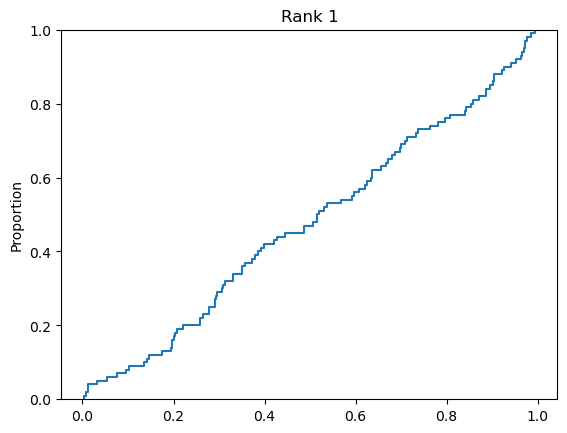

In [40]:
K_rank(n = 100, K = 20, rank = 1)

**6.** What distribution(s) does this process generate?

This process generates the beta distribution because as the rank changes, the ECDF changes in the same way as the Beta distribution for different values of a and b. When the ranks are smaller, the distribution looks logarithmic, and as the ranks are larger the distribution looks exponential. 

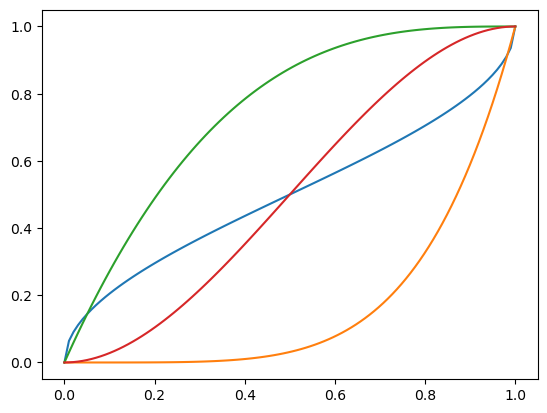

In [43]:
from scipy.stats import beta

x = np.linspace(0, 1, 100)
y1 = beta.cdf(x, 0.5, 0.5)
y2 = beta.cdf(x, 5, 1)
y3 = beta.cdf(x, 1, 3)
y4 = beta.cdf(x, 2, 2)

plt.plot(x, y1)
plt.plot(x, y2)
plt.plot(x, y3)
plt.plot(x, y4)
plt.show()